# Step 1: Load the Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
d1 = pd.read_csv("Customer_Master_Data.csv")
d2 = pd.read_csv("Customer_Transactions.csv")

In [3]:
d1

,CustomerID,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
0,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22
1,CUST10001,Divit Kohli,mkalita@sarin.com,Female,48,Kolkata,Married,0,2023-12-06
2,CUST10002,Kiara Behl,apteanay@hotmail.com,Male,75,Kolkata,Widowed,2,2023-08-23
3,CUST10003,Vaibhav Sankar,bseshadri@choudhry.info,Male,62,Pune,Divorced,2,2022-11-17
4,CUST10004,Shray D’Alia,bdhillon@toor-mall.com,Male,55,Delhi,Divorced,0,2022-12-04
...,...,...,...,...,...,...,...,...,...
995,CUST10995,Mehul Chada,hridaanagate@hotmail.com,Male,70,Hyderabad,Divorced,2,2020-07-29
996,CUST10996,Arhaan Tara,qwali@mand-sood.com,Male,35,Delhi,Single,1,2022-07-24
997,CUST10997,Mahika Uppal,vdalal@yahoo.com,Female,70,Ahmedabad,Married,3,2023-01-27
998,CUST10998,Bhamini Aggarwal,kartik15@bajaj-singhal.com,Male,37,Jaipur,Single,0,2022-07-22


In [4]:
d2

,CustomerID,TransactionDate,TransactionAmount
0,CUST10771,7/31/23,2383.07
1,CUST10100,3/10/24,497.54
2,CUST10031,2/17/25,536.78
3,CUST10987,7/17/23,314.89
4,CUST10831,12/15/24,2543.19
...,...,...,...
23045,CUST10710,3/11/24,931.09
23046,CUST10209,6/19/24,2659.35
23047,CUST10570,6/27/24,266.97
23048,CUST10075,12/26/23,1671.73


In [5]:
print(d1.shape,d2.shape)

(1000, 9) (23050, 3)


# Step 2: Data Cleaning

In [6]:
d1["JoinDate"] = pd.to_datetime(d1["JoinDate"])

In [7]:
d2["TransactionDate"] = pd.to_datetime(d2["TransactionDate"])

In [9]:
d1["JoinDate"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1000 entries, 0 to 999
Series name: JoinDate
Non-Null Count  Dtype         
--------------  -----         
1000 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 7.9 KB


In [10]:
d2["TransactionDate"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 23050 entries, 0 to 23049
Series name: TransactionDate
Non-Null Count  Dtype         
--------------  -----         
23050 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 180.2 KB


In [10]:
d1.isnull().sum()

CustomerID       0
Name             0
Email            0
Gender           0
Age              0
City             0
MaritalStatus    0
NumChildren      0
JoinDate         0
dtype: int64

In [11]:
d1.isnull().sum()

CustomerID       0
Name             0
Email            0
Gender           0
Age              0
City             0
MaritalStatus    0
NumChildren      0
JoinDate         0
dtype: int64

In [12]:
d1["CustomerID"].nunique()

1000

# Step 3: Merge Data

In [12]:
df = d1.merge(d2)

In [13]:
df

,CustomerID,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate,TransactionDate,TransactionAmount
0,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,2022-10-03,961.52
1,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,2024-05-31,92.16
2,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,2024-05-31,1153.74
3,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,2023-01-31,1217.04
4,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,2022-06-12,912.08
...,...,...,...,...,...,...,...,...,...,...,...
23045,CUST10999,Alia Sekhon,urvichadha@hotmail.com,Male,67,Hyderabad,Widowed,1,2021-09-07,2025-06-25,1883.60
23046,CUST10999,Alia Sekhon,urvichadha@hotmail.com,Male,67,Hyderabad,Widowed,1,2021-09-07,2025-02-12,243.54
23047,CUST10999,Alia Sekhon,urvichadha@hotmail.com,Male,67,Hyderabad,Widowed,1,2021-09-07,2024-10-09,1081.81
23048,CUST10999,Alia Sekhon,urvichadha@hotmail.com,Male,67,Hyderabad,Widowed,1,2021-09-07,2023-03-15,1619.39


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 23050 entries, 0 to 23049
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   CustomerID         23050 non-null  object        
 1   Name               23050 non-null  object        
 2   Email              23050 non-null  object        
 3   Gender             23050 non-null  object        
 4   Age                23050 non-null  int64         
 5   City               23050 non-null  object        
 6   MaritalStatus      23050 non-null  object        
 7   NumChildren        23050 non-null  int64         
 8   JoinDate           23050 non-null  datetime64[ns]
 9   TransactionDate    23050 non-null  datetime64[ns]
 10  TransactionAmount  23050 non-null  float64       
dtypes: datetime64[ns](2), float64(1), int64(2), object(6)
memory usage: 2.1+ MB


# Step 4: RFM Calculation

In [32]:
ref_date = df["TransactionDate"].max()+pd.Timedelta(days =1)

In [33]:
rfm = df.groupby("CustomerID").agg({"TransactionAmount":"sum", "CustomerID":"count"})

In [34]:
rfm.columns = ["Monetary","Frequency"]

In [35]:
rec= df.groupby("CustomerID").agg({"TransactionDate":"max"})

In [36]:
rfm["Recency"]=ref_date - rec

In [37]:
rfm["Recency"] = rfm["Recency"].dt.days

In [38]:
rfm

,Monetary,Frequency,Recency
CustomerID,,,
CUST10000,21265.49,23,13
CUST10001,28654.31,30,35
CUST10002,23884.03,24,18
CUST10003,24206.03,25,81
CUST10004,25565.30,19,8
...,...,...,...
CUST10995,24325.19,21,402
CUST10996,21809.11,21,15
CUST10997,21120.48,20,32


# Step 5: Score RFM

In [39]:
rfm["R_score"] = pd.qcut(rfm["Recency"],5,[5,4,3,2,1])
rfm["M_score"] = pd.qcut(rfm["Monetary"],5,[1,2,3,4,5])
rfm["F_score"] = pd.qcut(rfm["Frequency"],5,[1,2,3,4,5])

In [40]:
rfm

,Monetary,Frequency,Recency,R_score,M_score,F_score
CustomerID,,,,,,
CUST10000,21265.49,23,13,4,2,3
CUST10001,28654.31,30,35,3,5,5
CUST10002,23884.03,24,18,4,3,3
CUST10003,24206.03,25,81,1,3,4
CUST10004,25565.30,19,8,5,4,1
...,...,...,...,...,...,...
CUST10995,24325.19,21,402,1,3,2
CUST10996,21809.11,21,15,4,3,2
CUST10997,21120.48,20,32,3,2,2


# Step 6: Create Combined RFM Segment

In [50]:
rfm["RFM"] = rfm["R_score"].astype(str) + rfm["F_score"].astype(str) + rfm["M_score"].astype(str)

In [43]:
rfm

,Monetary,Frequency,Recency,R_score,M_score,F_score,RFM
CustomerID,,,,,,,
CUST10000,21265.49,23,13,4,2,3,432
CUST10001,28654.31,30,35,3,5,5,355
CUST10002,23884.03,24,18,4,3,3,433
CUST10003,24206.03,25,81,1,3,4,143
CUST10004,25565.30,19,8,5,4,1,514
...,...,...,...,...,...,...,...
CUST10995,24325.19,21,402,1,3,2,123
CUST10996,21809.11,21,15,4,3,2,423
CUST10997,21120.48,20,32,3,2,2,322


# Step 7: Assign Segment Labels

In [62]:
def segment(row):
    if row['RFM'] == "555":
        return 'Champion'
    elif row['RFM'] == "111":
        return "Lost"
    else:
        return "Normal"
rfm["Segment"] = rfm.apply(segment, axis=1)

In [63]:
rfm

,Monetary,Frequency,Recency,R_score,M_score,F_score,RFM,Segment
CustomerID,,,,,,,,
CUST10000,21265.49,23,13,4,2,3,432,Normal
CUST10001,28654.31,30,35,3,5,5,355,Normal
CUST10002,23884.03,24,18,4,3,3,433,Normal
CUST10003,24206.03,25,81,1,3,4,143,Normal
CUST10004,25565.30,19,8,5,4,1,514,Normal
...,...,...,...,...,...,...,...,...
CUST10995,24325.19,21,402,1,3,2,123,Normal
CUST10996,21809.11,21,15,4,3,2,423,Normal
CUST10997,21120.48,20,32,3,2,2,322,Normal


# Step 8: Visualization

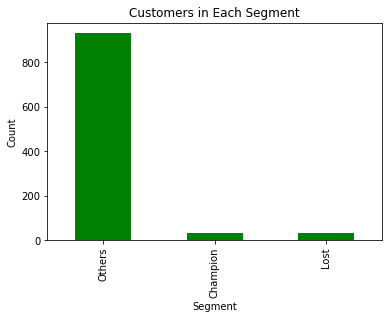

In [59]:
rfm["Segment"].value_counts().plot(kind="bar", color="Green")
plt.title("Customers in Each Segment")
plt.xlabel("Segment")
plt.ylabel("Count")
plt.show()

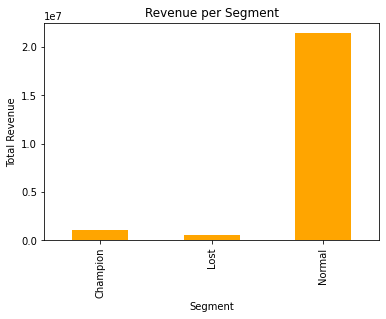

In [68]:
revenue = rfm.groupby("Segment")["Monetary"].sum()
revenue.plot(kind="bar", color="orange")
plt.title("Revenue per Segment")
plt.xlabel("Segment")
plt.ylabel("Total Revenue")
plt.show()

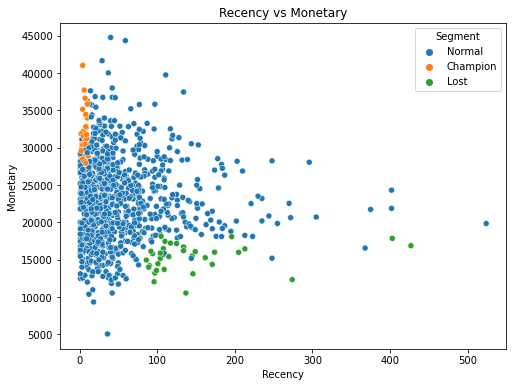

In [64]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm,x="Recency",y="Monetary",hue="Segment")
plt.title("Recency vs Monetary")
plt.show()

In [69]:
rfm_sorted = rfm.sort_values(by='Monetary', ascending=False)

In [70]:
rfm_sorted['cum_revenue'] = rfm_sorted['Monetary'].cumsum()
rfm_sorted['cum_percent'] = rfm_sorted['cum_revenue'] / rfm_sorted['Monetary'].sum()

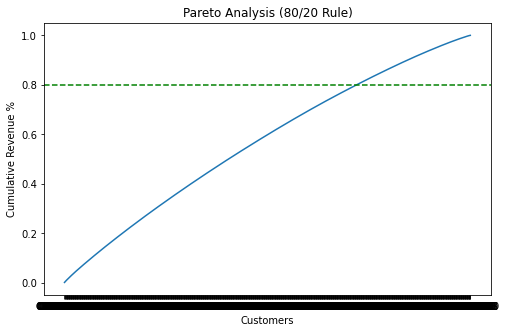

In [78]:
plt.figure(figsize=(8,5))
plt.plot(rfm_sorted["cum_percent"])
plt.axhline(y=0.8, color="green", linestyle="--")
plt.title("Pareto Analysis (80/20 Rule)")
plt.xlabel("Customers")
plt.ylabel("Cumulative Revenue %")
plt.show()